# DRO-Huffman Coding: Progressive Flattening with the English Alphabet

This notebook demonstrates how Distributionally Robust Optimization (DRO) applied to Huffman coding
progressively flattens codeword lengths as distributional uncertainty $\varepsilon$ increases.

With 26 letters and their English frequency distribution, we observe **smooth transitions**
through multiple intermediate codes as $\varepsilon$ grows from 0 (standard Huffman) toward
the uniform code.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

## 1. English letter frequencies

In [26]:
freq_table = {
    'E': 12.70, 'T': 9.06, 'A': 8.17, 'O': 7.51, 'I': 6.97,
    'N': 6.75, 'S': 6.33, 'H': 6.09, 'R': 5.99, 'D': 4.25,
    'L': 4.03, 'C': 2.78, 'U': 2.76, 'M': 2.41, 'W': 2.36,
    'F': 2.23, 'G': 2.02, 'Y': 1.97, 'P': 1.93, 'B': 1.29,
    'V': 0.98, 'K': 0.77, 'J': 0.15, 'X': 0.15, 'Q': 0.10,
    'Z': 0.07,
}

sorted_items = sorted(freq_table.items(), key=lambda x: -x[1])
symbols = [s for s, _ in sorted_items]
probs = np.array([f for _, f in sorted_items])
probs = probs / probs.sum()
n = len(symbols)

H = -np.sum(probs * np.log2(probs))
print(f"Alphabet size: {n}")
print(f"Shannon entropy: {H:.4f} bits")
print(f"Uniform code: ceil(log2({n})) = {int(np.ceil(np.log2(n)))} bits")
print(f"\nTop 5:    {', '.join(f'{s}:{p:.4f}' for s, p in zip(symbols[:5], probs[:5]))}")
print(f"Bottom 5: {', '.join(f'{s}:{p:.4f}' for s, p in zip(symbols[-5:], probs[-5:]))}")
print(f"Ratio max/min: {probs[0]/probs[-1]:.0f}x")

Alphabet size: 26
Shannon entropy: 4.1717 bits
Uniform code: ceil(log2(26)) = 5 bits

Top 5:    E:0.1272, T:0.0908, A:0.0818, O:0.0752, I:0.0698
Bottom 5: K:0.0077, J:0.0015, X:0.0015, Q:0.0010, Z:0.0007
Ratio max/min: 181x


## 2. Standard Huffman coding

In [27]:
def build_huffman_lengths(probs):
    """Build a Huffman tree and return codeword lengths."""
    n = len(probs)
    heap = [(p, i, i) for i, p in enumerate(probs)]
    heapq.heapify(heap)
    counter = n
    while len(heap) > 1:
        p1, _, n1 = heapq.heappop(heap)
        p2, _, n2 = heapq.heappop(heap)
        heapq.heappush(heap, (p1 + p2, counter, (n1, n2)))
        counter += 1
    lengths = [0] * n
    def traverse(node, depth):
        if isinstance(node, int):
            lengths[node] = depth
            return
        traverse(node[0], depth + 1)
        traverse(node[1], depth + 1)
    traverse(heap[0][2], 0)
    return np.array(lengths)


huff_lengths = build_huffman_lengths(probs)
huff_expected = float(probs @ huff_lengths)

print("Standard Huffman code:")
print(f"{'Sym':<5} {'Prob':>7} {'Len':>5}")
print("-" * 19)
for s, p, l in zip(symbols, probs, huff_lengths):
    print(f"  {s:<3} {p:>7.4f} {l:>5}")
print(f"\nExpected length:  {huff_expected:.4f} bits")
print(f"Shannon entropy:  {H:.4f} bits")
print(f"Redundancy:       {huff_expected - H:.4f} bits")
print(f"Length range:     [{min(huff_lengths)}, {max(huff_lengths)}]  (spread={max(huff_lengths)-min(huff_lengths)})")
print(f"Kraft sum:        {np.sum(2.0 ** (-huff_lengths.astype(float))):.6f}")

Standard Huffman code:
Sym      Prob   Len
-------------------
  E    0.1272     3
  T    0.0908     3
  A    0.0818     4
  O    0.0752     4
  I    0.0698     4
  N    0.0676     4
  S    0.0634     4
  H    0.0610     4
  R    0.0600     4
  D    0.0426     5
  L    0.0404     5
  C    0.0279     5
  U    0.0276     5
  M    0.0241     5
  W    0.0236     5
  F    0.0223     5
  G    0.0202     6
  Y    0.0197     6
  P    0.0193     6
  B    0.0129     6
  V    0.0098     6
  K    0.0077     7
  J    0.0015     9
  X    0.0015     9
  Q    0.0010     9
  Z    0.0007     9

Expected length:  4.2014 bits
Shannon entropy:  4.1717 bits
Redundancy:       0.0297 bits
Length range:     [3, 9]  (spread=6)
Kraft sum:        1.000000


## 3. DRO worst-case risk

For $W_1$ with trivial metric $d(a_i, a_j) = \mathbf{1}_{i \neq j}$:

$$\mathcal{R}_\varepsilon(\hat{P}, l) = \inf_{\lambda \geq 0}\left\{\lambda\varepsilon + \sum_{i=1}^n \hat{p}_i\,\max(l_i,\; M_i - \lambda)\right\}$$

where $M_i = \max_{j \neq i} l_j$.

For sorted non-decreasing lengths, $M_i = l_{\max}$ for all symbols except those
already at $l_{\max}$ (where $M_i$ = second largest length).

In [28]:
def dro_worst_case_risk(lengths, probs, epsilon):
    """DRO worst-case expected codeword length under W1 with trivial metric."""
    lengths = np.asarray(lengths, dtype=float)
    n = len(lengths)
    l_max = lengths.max()

    unique_lengths = np.unique(lengths)
    if len(unique_lengths) == 1:
        # All lengths equal: adversary gains nothing
        return float(probs @ lengths)

    second_max = unique_lengths[-2]
    M = np.where(lengths < l_max, l_max, second_max)

    gaps = M - lengths
    candidates = {0.0}
    for g in gaps:
        if g > 0:
            candidates.add(float(g))

    best = float('inf')
    for lam in candidates:
        val = lam * epsilon + float(np.sum(probs * np.maximum(lengths, M - lam)))
        best = min(best, val)
    return best

## 4. Enumerate feasible codes via length profiles

A **length profile** $(n_1, n_2, \ldots, n_L)$ specifies how many symbols get codeword length $j$.
Given sorted probabilities, the assignment is deterministic: the $n_1$ most probable symbols
get length 1, the next $n_2$ get length 2, etc.

Constraints: $\sum_j n_j = 26$, $\quad\sum_j n_j \cdot 2^{-j} \leq 1$

In [29]:
def generate_profiles(n_symbols, max_length=9, min_kraft=0.75):
    """Generate valid length profiles with Kraft floor pruning.

    Only keeps profiles with Kraft sum >= min_kraft, since codes wasting
    too much Kraft budget are never DRO-optimal.
    """
    profiles = []
    profile = [0] * max_length

    def backtrack(level_idx, remaining, kraft_used):
        if remaining == 0:
            if kraft_used >= min_kraft - 1e-10:
                profiles.append(profile[:])
            return
        if level_idx >= max_length:
            return

        kraft_cost = 2.0 ** (-(level_idx + 1))
        max_here = min(remaining, int((1.0 - kraft_used) / kraft_cost + 1e-9))

        for k in range(max_here, -1, -1):
            new_remaining = remaining - k
            new_kraft = kraft_used + k * kraft_cost

            if new_remaining > 0:
                # Prune: remaining symbols need at least this much Kraft
                min_additional = new_remaining * 2.0 ** (-max_length)
                if new_kraft + min_additional > 1.0 + 1e-10:
                    continue
                # Prune: even putting all remaining at the shallowest next level
                # won't reach min_kraft
                if level_idx + 1 < max_length:
                    max_additional = new_remaining * 2.0 ** (-(level_idx + 2))
                    if new_kraft + max_additional < min_kraft - 1e-10:
                        continue

            profile[level_idx] = k
            backtrack(level_idx + 1, new_remaining, new_kraft)
        profile[level_idx] = 0

    backtrack(0, n_symbols, 0.0)
    return profiles


def profile_to_lengths(prof):
    """Convert a profile to a non-decreasing length vector."""
    lengths = []
    for level_idx, count in enumerate(prof):
        lengths.extend([level_idx + 1] * count)
    return np.array(lengths, dtype=np.int32)


print("Generating feasible length profiles (max_length=9, min_kraft=0.75)...")
profiles = generate_profiles(n, max_length=9, min_kraft=0.75)
feasible_codes = [profile_to_lengths(p) for p in profiles]
print(f"Found {len(feasible_codes)} feasible codes.")

huff_sorted = np.sort(huff_lengths)
found = any(np.array_equal(c, huff_sorted) for c in feasible_codes)
print(f"Huffman code in feasible set: {found}")

Generating feasible length profiles (max_length=9, min_kraft=0.75)...
Found 644928 feasible codes.
Huffman code in feasible set: True


In [30]:
## Precompute batch data for vectorized DRO evaluation

all_lengths = np.array(feasible_codes, dtype=np.float32)  # (N_codes, 26)
N_codes = all_lengths.shape[0]

# For each code: l_max, second_max, and M matrix
l_max_vec = all_lengths[:, -1]  # codes are sorted non-decreasing, so last = max

# Second largest length per code
mask = all_lengths < l_max_vec[:, None]
masked_lengths = np.where(mask, all_lengths, -np.inf)
second_max = masked_lengths.max(axis=1)
all_equal = ~mask.any(axis=1)
second_max[all_equal] = l_max_vec[all_equal]

# M[c, i] = l_max if l_i < l_max, else second_max
M = np.where(all_lengths < l_max_vec[:, None], l_max_vec[:, None], second_max[:, None])

# Lambda candidates: breakpoints are integers from 0 to max possible gap
max_gap = int((l_max_vec - all_lengths[:, 0]).max())
lambda_candidates = np.arange(0, max_gap + 1, dtype=np.float32)

# Precompute inflated_sums[code, lambda_idx] = sum_i p_i * max(l_i, M_i - lambda)
inflated_sums = np.empty((N_codes, len(lambda_candidates)), dtype=np.float32)
probs_f32 = probs.astype(np.float32)

for li, lam in enumerate(lambda_candidates):
    inflated = np.maximum(all_lengths, M - lam)
    inflated_sums[:, li] = (inflated * probs_f32[None, :]).sum(axis=1)

print(f"Precomputed {N_codes} codes × {len(lambda_candidates)} lambda values")
print(f"Lambda range: [0, {max_gap}]")
print(f"inflated_sums shape: {inflated_sums.shape}")
print(f"Memory: {inflated_sums.nbytes / 1e6:.1f} MB")

Precomputed 644928 codes × 9 lambda values
Lambda range: [0, 8]
inflated_sums shape: (644928, 9)
Memory: 23.2 MB


## 5. Find DRO-optimal code for each $\varepsilon$

In [37]:
epsilons = np.linspace(0, 0.75, 300)

# For each epsilon: risk(code, lambda) = inflated_sums[code, lambda] + lambda * epsilon
# Optimal: min over lambda, then min over codes
optimal_indices = np.empty(len(epsilons), dtype=int)
optimal_risks = np.empty(len(epsilons))

for ei, eps in enumerate(epsilons):
    # (N_codes, n_lambdas) + (1, n_lambdas) * scalar
    risk_per_lambda = inflated_sums + lambda_candidates[None, :] * eps
    min_risk_per_code = risk_per_lambda.min(axis=1)  # best lambda for each code
    best_idx = int(min_risk_per_code.argmin())
    optimal_risks[ei] = min_risk_per_code[best_idx]
    optimal_indices[ei] = best_idx

optimal_codes = [feasible_codes[i] for i in optimal_indices]
optimal_lengths_array = np.array(optimal_codes)

# Huffman risks (vectorized)
huff_sorted = np.sort(huff_lengths)
huff_idx = next(i for i, c in enumerate(feasible_codes) if np.array_equal(c, huff_sorted))
huffman_risks = np.array([
    float((inflated_sums[huff_idx] + lambda_candidates * eps).min())
    for eps in epsilons
])

print("Done.")

Done.


## 6. Distinct codes selected by DRO

As $\varepsilon$ increases, the DRO selects **multiple intermediate codes**
with progressively smaller length spreads.

In [38]:
transitions = []
prev_code = None
for eps, code in zip(epsilons, optimal_codes):
    code_tuple = tuple(code)
    if code_tuple != prev_code:
        transitions.append((eps, code))
        prev_code = code_tuple

print(f"Number of distinct DRO-optimal codes: {len(transitions)}\n")
print(f"{'eps':>8} {'spread':>6} {'lmin':>5} {'lmax':>5} {'E[L]':>7} {'Kraft':>7}   profile")
print("-" * 80)

for eps_start, code in transitions:
    spread = int(max(code) - min(code))
    nominal = float(probs @ code)
    kraft = float(np.sum(2.0 ** (-code.astype(float))))
    unique, counts = np.unique(code, return_counts=True)
    prof_str = ', '.join(f'{c}x{l}bit' for l, c in zip(unique, counts))
    print(f"{eps_start:>8.4f} {spread:>6} {int(min(code)):>5} {int(max(code)):>5} {nominal:>7.3f} {kraft:>7.4f}   {prof_str}")

Number of distinct DRO-optimal codes: 6

     eps spread  lmin  lmax    E[L]   Kraft   profile
--------------------------------------------------------------------------------
  0.0000      6     3     9   4.201  1.0000   2x3bit, 7x4bit, 7x5bit, 5x6bit, 1x7bit, 4x9bit
  0.0075      5     3     8   4.206  1.0000   2x3bit, 7x4bit, 7x5bit, 4x6bit, 2x7bit, 4x8bit
  0.0201      4     3     7   4.224  1.0000   2x3bit, 7x4bit, 6x5bit, 5x6bit, 6x7bit
  0.0477      2     4     6   4.315  1.0000   11x4bit, 5x5bit, 10x6bit
  0.1731      1     4     5   4.487  1.0000   6x4bit, 20x5bit
  0.5142      2     3     5   4.564  1.0000   2x3bit, 24x5bit


## 7. Progressive flattening of codeword lengths

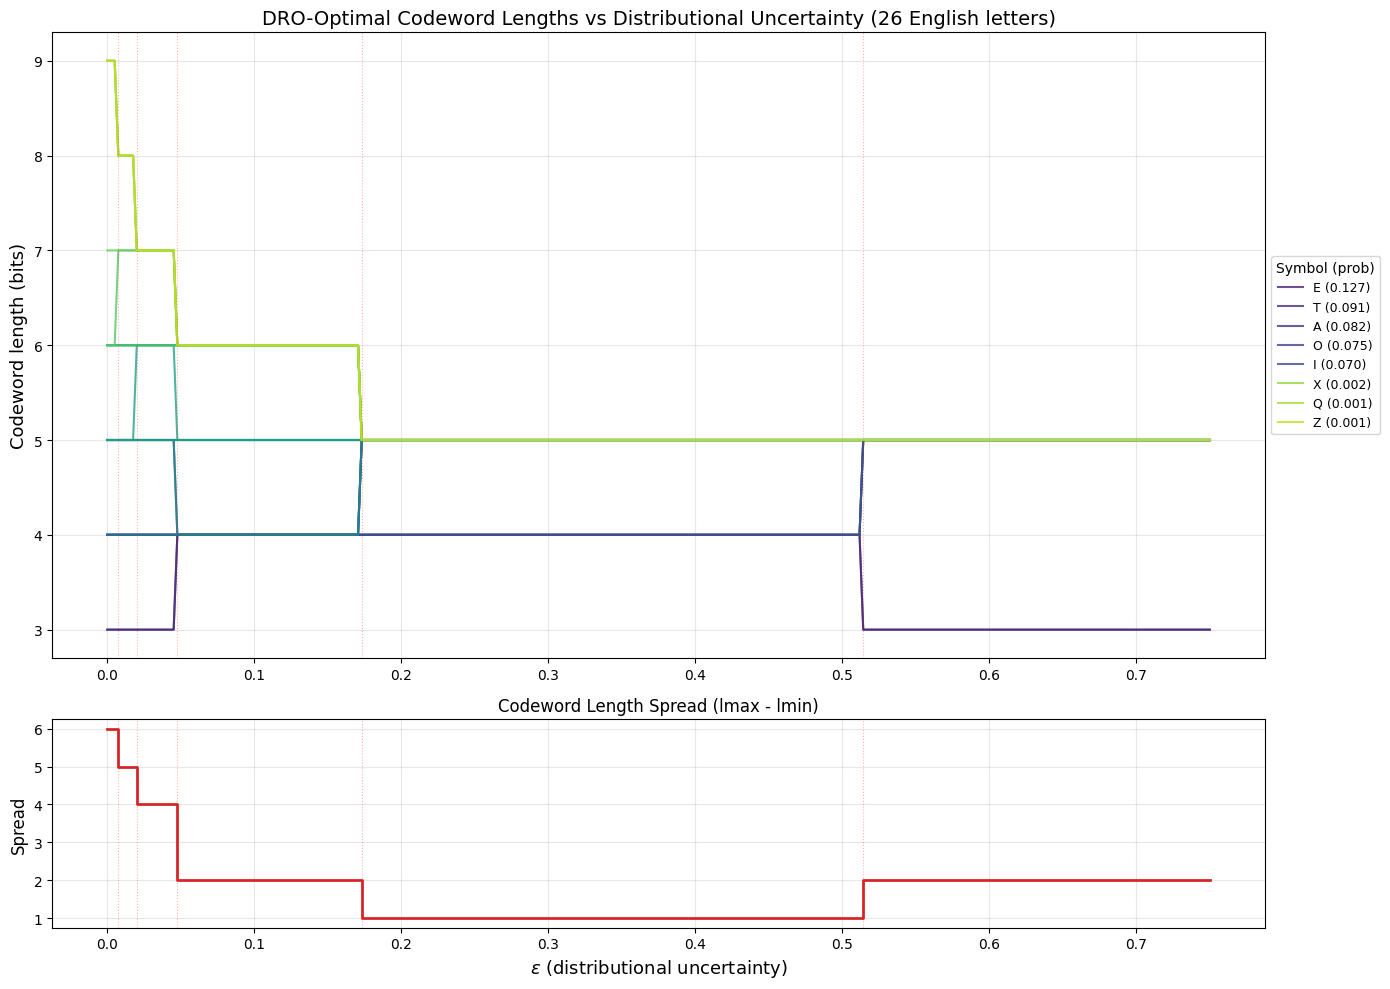

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, n))

for i in range(n):
    label = f"{symbols[i]} ({probs[i]:.3f})" if i < 5 or i >= n - 3 else None
    ax.plot(epsilons, optimal_lengths_array[:, i],
            color=cmap[i], linewidth=1.5, alpha=0.8, label=label)

ax.set_ylabel('Codeword length (bits)', fontsize=13)
ax.set_title('DRO-Optimal Codeword Lengths vs Distributional Uncertainty (26 English letters)', fontsize=14)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, title='Symbol (prob)')
ax.grid(True, alpha=0.3)

for eps_start, _ in transitions[1:]:
    ax.axvline(x=eps_start, color='red', linestyle=':', alpha=0.3, linewidth=0.8)

ax2 = axes[1]
spreads_plot = [int(max(c) - min(c)) for c in optimal_codes]
ax2.step(epsilons, spreads_plot, linewidth=2, color='C3', where='post')
ax2.set_xlabel(r'$\varepsilon$ (distributional uncertainty)', fontsize=13)
ax2.set_ylabel('Spread', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_title('Codeword Length Spread (lmax - lmin)', fontsize=12)

for eps_start, _ in transitions[1:]:
    ax2.axvline(x=eps_start, color='red', linestyle=':', alpha=0.3, linewidth=0.8)

plt.tight_layout()
plt.show()

## 8. Worst-case risk comparison

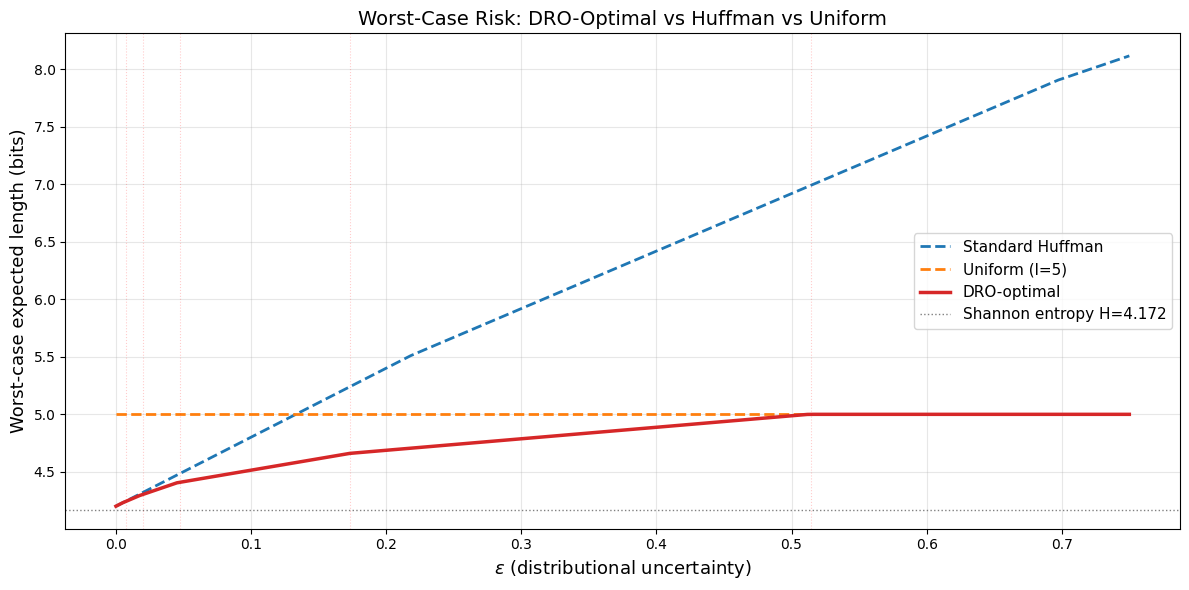

In [40]:
uniform_length = int(np.ceil(np.log2(n)))
uniform_lengths = np.full(n, uniform_length)
uniform_risks = np.array([dro_worst_case_risk(uniform_lengths, probs, eps) for eps in epsilons])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epsilons, huffman_risks, '--', label='Standard Huffman', linewidth=2, color='C0')
ax.plot(epsilons, uniform_risks, '--', label=f'Uniform (l={uniform_length})', linewidth=2, color='C1')
ax.plot(epsilons, optimal_risks, '-', label='DRO-optimal', linewidth=2.5, color='C3')
ax.axhline(y=H, color='gray', linestyle=':', label=f'Shannon entropy H={H:.3f}', linewidth=1)

for eps_start, _ in transitions[1:]:
    ax.axvline(x=eps_start, color='red', linestyle=':', alpha=0.2, linewidth=0.8)

ax.set_xlabel(r'$\varepsilon$ (distributional uncertainty)', fontsize=13)
ax.set_ylabel('Worst-case expected length (bits)', fontsize=13)
ax.set_title('Worst-Case Risk: DRO-Optimal vs Huffman vs Uniform', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Statistical calibration

$$\varepsilon_N(\delta) = \sqrt{\frac{\ln(2/\delta)}{2N}}$$

In [41]:
def epsilon_from_samples(N, delta=0.05):
    return np.sqrt(np.log(2.0 / delta) / (2 * N))


sample_sizes = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
delta = 0.05

print(f"Statistical calibration (confidence = {1-delta:.0%})\n")
print(f"{'N':>8} {'eps':>8} {'spread':>7} {'lmin':>5} {'lmax':>5} {'E[L]':>7} {'WC risk':>8}  profile")
print("-" * 85)

for N in sample_sizes:
    eps = epsilon_from_samples(N, delta)
    # Vectorized: compute risk for all codes at this epsilon
    risk_per_lambda = inflated_sums + lambda_candidates[None, :] * eps
    min_risk_per_code = risk_per_lambda.min(axis=1)
    best_idx = int(min_risk_per_code.argmin())
    best_risk = float(min_risk_per_code[best_idx])
    best_code = feasible_codes[best_idx]

    spread = int(max(best_code) - min(best_code))
    unique, counts = np.unique(best_code, return_counts=True)
    prof_str = ', '.join(f'{c}x{l}b' for l, c in zip(unique, counts))
    print(f"{N:>8} {eps:>8.4f} {spread:>7} {int(min(best_code)):>5} {int(max(best_code)):>5} "
          f"{float(probs @ best_code):>7.3f} {best_risk:>8.4f}  {prof_str}")

Statistical calibration (confidence = 95%)

       N      eps  spread  lmin  lmax    E[L]  WC risk  profile
-------------------------------------------------------------------------------------
      10   0.4295       1     4     5   4.487   4.9169  6x4b, 20x5b
      25   0.2716       1     4     5   4.487   4.7591  6x4b, 20x5b
      50   0.1921       1     4     5   4.487   4.6795  6x4b, 20x5b
     100   0.1358       2     4     6   4.315   4.5862  11x4b, 5x5b, 10x6b
     250   0.0859       2     4     6   4.315   4.4864  11x4b, 5x5b, 10x6b
     500   0.0607       2     4     6   4.315   4.4360  11x4b, 5x5b, 10x6b
    1000   0.0429       4     3     7   4.224   4.3959  2x3b, 7x4b, 6x5b, 5x6b, 6x7b
    2500   0.0272       4     3     7   4.224   4.3328  2x3b, 7x4b, 6x5b, 5x6b, 6x7b
    5000   0.0192       4     3     7   4.224   4.3009  2x3b, 7x4b, 6x5b, 5x6b, 6x7b
   10000   0.0136       5     3     8   4.206   4.2744  2x3b, 7x4b, 7x5b, 4x6b, 2x7b, 4x8b


## 10. Convergence to Huffman as $N$ grows

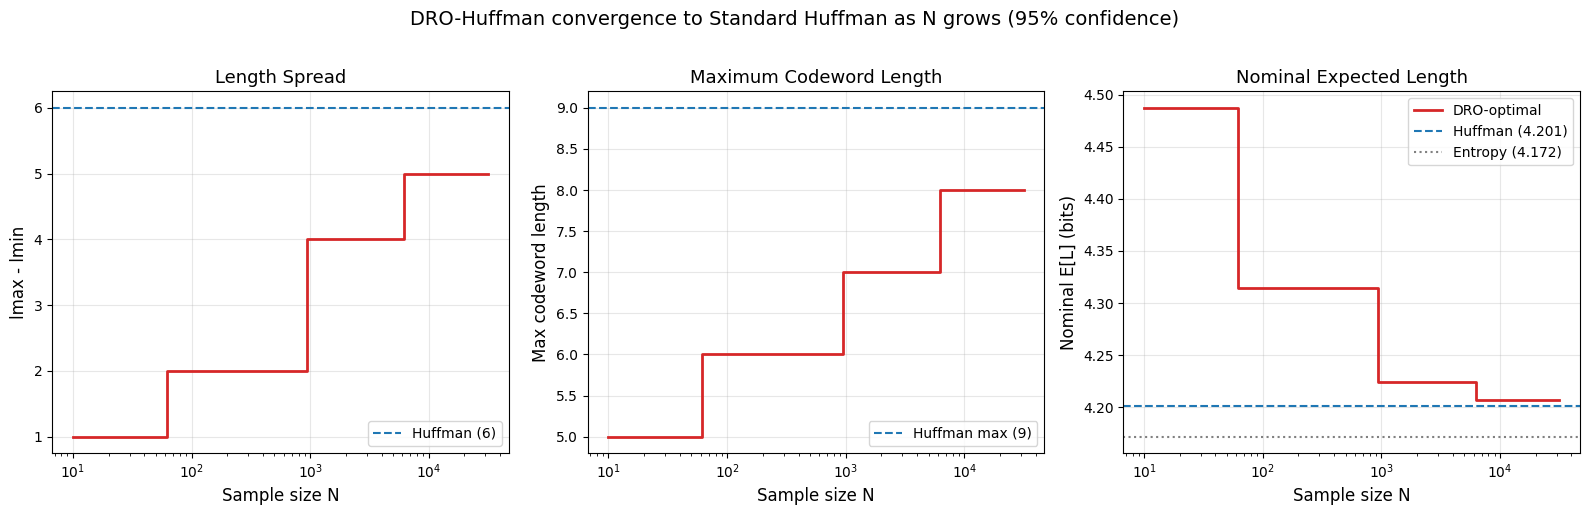

In [42]:
N_range = np.unique(np.logspace(1, 4.5, 150).astype(int))

spreads = []
max_lens = []
nom_lens = []

for N in N_range:
    eps = epsilon_from_samples(N, delta=0.05)
    risk_per_lambda = inflated_sums + lambda_candidates[None, :] * eps
    min_risk_per_code = risk_per_lambda.min(axis=1)
    best_idx = int(min_risk_per_code.argmin())
    best_code = feasible_codes[best_idx]
    spreads.append(int(max(best_code) - min(best_code)))
    max_lens.append(int(max(best_code)))
    nom_lens.append(float(probs @ best_code))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].step(N_range, spreads, linewidth=2, color='C3', where='post')
axes[0].axhline(y=max(huff_lengths) - min(huff_lengths), color='C0', linestyle='--',
                label=f'Huffman ({max(huff_lengths)-min(huff_lengths)})')
axes[0].set_xlabel('Sample size N', fontsize=12)
axes[0].set_ylabel('lmax - lmin', fontsize=12)
axes[0].set_title('Length Spread', fontsize=13)
axes[0].set_xscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].step(N_range, max_lens, linewidth=2, color='C3', where='post')
axes[1].axhline(y=max(huff_lengths), color='C0', linestyle='--',
                label=f'Huffman max ({max(huff_lengths)})')
axes[1].set_xlabel('Sample size N', fontsize=12)
axes[1].set_ylabel('Max codeword length', fontsize=12)
axes[1].set_title('Maximum Codeword Length', fontsize=13)
axes[1].set_xscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

axes[2].step(N_range, nom_lens, linewidth=2, color='C3', label='DRO-optimal', where='post')
axes[2].axhline(y=huff_expected, color='C0', linestyle='--',
                label=f'Huffman ({huff_expected:.3f})')
axes[2].axhline(y=H, color='gray', linestyle=':', label=f'Entropy ({H:.3f})')
axes[2].set_xlabel('Sample size N', fontsize=12)
axes[2].set_ylabel('Nominal E[L] (bits)', fontsize=12)
axes[2].set_title('Nominal Expected Length', fontsize=13)
axes[2].set_xscale('log')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('DRO-Huffman convergence to Standard Huffman as N grows (95% confidence)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()